# AgriSense — Data Preparation & Cleaning

This notebook prepares the PlantSeg dataset for machine learning.

The raw dataset was first investigated in `01_eda.ipynb`.

The EDA identified several data-quality issues, including duplicate images, conflicting disease labels, cross-split duplicates, class imbalance, and varying image dimensions.

The goal of this notebook is to create a reliable dataset for model training while avoiding data leakage and preserving as much valid information as possible.

In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import hashlib
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
#Loading the metadata

#Define the project root
project_root = Path.cwd().parent

#Define important data paths
metadata_path = project_root / "data" / "raw" / "PlantSeg"
image_dir = metadata_path / "images"

#Load the metadata
metadata_file = metadata_path / "metadata.csv"

df=pd.read_csv(metadata_file)

print("project root" , project_root)
print("Image Directory",image_dir)
print("metadata Shape",df.shape)
print("Metadata columns",df.columns.tolist())

project root c:\Users\Dell\Documents\Projects\AgriSense
Image Directory c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images
metadata Shape (7774, 10)
Metadata columns ['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split']


In [3]:
#initial record values

print("Initial Dataset size : ",len(df))
print("Number of plants : ", df["Plant"].nunique())
print("Number of Diseases : ",df["Disease"].nunique())

print("Split Distribution : \n",df["Split"].value_counts())
print("Missing values : ", df.isnull().sum().sum())

Initial Dataset size :  7774
Number of plants :  34
Number of Diseases :  115
Split Distribution : 
 Split
Training      5367
Test          1561
Validation     846
Name: count, dtype: int64
Missing values :  0


In [4]:
#create image hashes 

def calculate_md5(file_path):
    """returns the MD5 hash of an image file"""

    with open(file_path,"rb") as f:
        return hashlib.md5(f.read()).hexdigest()

print("Hash function created successfuly!")

Hash function created successfuly!


In [5]:
image_lookup = {}

for image_path in image_dir.rglob("*"):

    if image_path.is_file():
        image_lookup[image_path.name] = image_path

print("Images found = ",len(image_lookup))

Images found =  7774


In [6]:
# Calculate the MD5 hash for every image

df["image_hash"] = df["Name"].map(
    lambda filename: calculate_md5(image_lookup[filename])
)

print("Hashes calculated:", df["image_hash"].notna().sum())
print("Unique image contents:", df["image_hash"].nunique())

Hashes calculated: 7774
Unique image contents: 7497


In [7]:
#Finding image contents that occur mor than once

duplicate_counts = df["image_hash"].value_counts()

duplicate_hashes = duplicate_counts[
    duplicate_counts > 1
].index

duplicate_records = df[
    df["image_hash"].isin(duplicate_hashes)
].sort_values("image_hash")

print("Records belonging to duplicate groups:", len(duplicate_records))
print("Number of duplicate image groups:", len(duplicate_hashes))

Records belonging to duplicate groups: 542
Number of duplicate image groups: 265


In [8]:
#Summarize each duplicate image group

duplicate_summary = (
    duplicate_records
    .groupby("image_hash")
    .agg(
        records = ("Name","count"),
        diseases = ("Disease","nunique"),
        plants = ("Plant","nunique"),
        splits = ("Split","nunique")
    )
    .reset_index()
)

print(duplicate_summary.head())

print("Number of duplicate group : ",len(duplicate_summary))

                         image_hash  records  diseases  plants  splits
0  010baf1a0f09318a09c9b144d4447242        2         2       1       2
1  0187ea51a7e765edfc02691ce1f3c737        2         2       2       2
2  0251ad19b65433696a01f07aa21197bd        2         1       1       2
3  03672baf1a488539501ffaa8f151c7d5        2         1       1       2
4  0688b47a55dd1f46873b84e5567631e4        2         2       2       1
Number of duplicate group :  265


In [9]:
#categorize duplicate image groups by disease and split consistency

same_disease = duplicate_summary["diseases"] == 1
same_plant = duplicate_summary["plants"] == 1
same_split = duplicate_summary["splits"] == 1

print("Duplicate groups with same disease:",
      same_disease.sum())

print("Duplicate groups with conflicting diseases:",
      (~same_disease).sum())

print("Duplicate groups within one split:",
      same_split.sum())

print("Duplicate groups across multiple splits:",
      (~same_split).sum())

Duplicate groups with same disease: 167
Duplicate groups with conflicting diseases: 98
Duplicate groups within one split: 142
Duplicate groups across multiple splits: 123


In [10]:
#Identify image contents with conflicting disease labels

conflicting_hashes = duplicate_summary.loc[
    duplicate_summary["diseases"] > 1,
    "image_hash"
]

print("Conflicting image contents : ",len(conflicting_hashes))

Conflicting image contents :  98


In [11]:
#creating a decision table for duplicate image groups

duplicate_decisions = duplicate_summary.copy()

duplicate_decisions["conflicting_disease"] =(duplicate_decisions["diseases"] > 1) 

duplicate_decisions["conflicting_plant"] = (duplicate_decisions["plants"] > 1)

duplicate_decisions["cross_split"] = (duplicate_decisions["splits"] > 1)

print(duplicate_decisions.head())

                         image_hash  records  diseases  plants  splits  \
0  010baf1a0f09318a09c9b144d4447242        2         2       1       2   
1  0187ea51a7e765edfc02691ce1f3c737        2         2       2       2   
2  0251ad19b65433696a01f07aa21197bd        2         1       1       2   
3  03672baf1a488539501ffaa8f151c7d5        2         1       1       2   
4  0688b47a55dd1f46873b84e5567631e4        2         2       2       1   

   conflicting_disease  conflicting_plant  cross_split  
0                 True              False         True  
1                 True               True         True  
2                False              False         True  
3                False              False         True  
4                 True               True        False  


In [12]:
# Cross-tabulate duplicate groups by disease consistency and split consistency

decision_matrix = pd.crosstab(
    duplicate_decisions["conflicting_disease"],
    duplicate_decisions["cross_split"]
)

print(decision_matrix)

cross_split          False  True 
conflicting_disease              
False                   96     71
True                    46     52


In [13]:
#check for duplicate image content with conflicting plant labels

plant_conflict_only = duplicate_decisions.loc[
    (duplicate_decisions["conflicting_plant"]) & 
    (~duplicate_decisions["conflicting_disease"])
]

print("Duplicate groups with conflicting plant labels but consistent disease labels : ",len(plant_conflict_only))

Duplicate groups with conflicting plant labels but consistent disease labels :  0


In [14]:
#counting all records belonging to conflicting plant labels

conflicting_records = df[
    df["image_hash"].isin(conflicting_hashes)
]

print("Conflicting image contents : ",len(conflicting_records))
print("records to be excluded : ",len(conflicting_records))

Conflicting image contents :  205
records to be excluded :  205


In [15]:
#creating a copy containing only records with consistent labels

df_clean = df[
    ~df["image_hash"].isin(conflicting_hashes)
].copy()

print("Original df : ", len(df))
print("df after removing conflicts ", len(df_clean))
print("records removed : ", len(df) - len(df_clean))

Original df :  7774
df after removing conflicts  7569
records removed :  205


In [16]:
# Find duplicate image contents remaining after conflict removal

remaining_duplicate_counts = df_clean["image_hash"].value_counts()

remaining_duplicate_hashes = remaining_duplicate_counts[
    remaining_duplicate_counts > 1
].index

print("Remaining duplicate groups:",
      len(remaining_duplicate_hashes))

print("Records belonging to remaining duplicate groups:",
      df_clean["image_hash"].isin(remaining_duplicate_hashes).sum())

Remaining duplicate groups: 167
Records belonging to remaining duplicate groups: 337


In [17]:
# Analyze the remaining duplicate groups by split

remaining_duplicate_summary = (
    df_clean[df_clean["image_hash"].isin(remaining_duplicate_hashes)]
    .groupby("image_hash")
    .agg(
        records=("Name", "count"),
        diseases=("Disease", "nunique"),
        plants=("Plant", "nunique"),
        splits=("Split", "nunique")
    )
    .reset_index()
)

remaining_duplicate_summary["cross_split"] = (
    remaining_duplicate_summary["splits"] > 1
)

print(
    "Duplicate groups within the same split:",
    (~remaining_duplicate_summary["cross_split"]).sum()
)

print(
    "Duplicate groups across multiple splits:",
    remaining_duplicate_summary["cross_split"].sum()
)

Duplicate groups within the same split: 96
Duplicate groups across multiple splits: 71


In [18]:
#Inspect the split assignment of the 71 cross split duplicate groups 

cross_split_groups = remaining_duplicate_summary[
    remaining_duplicate_summary["cross_split"]
].copy()

cross_split_details = (
    df_clean[
    df_clean["image_hash"].isin(cross_split_groups["image_hash"])
    ]
    .groupby("image_hash")
    .agg(
        files = ("Name", list),
        plants = ("Plant", list),
        diseases = ("Disease", list),
        splits = ("Split", list)
    )
    .reset_index()
)

print("Cross-split duplicate groups:", len(cross_split_details))

display(cross_split_details.head(10))

Cross-split duplicate groups: 71


,image_hash,files,plants,diseases,splits
0,0251ad19b65433696a01f07aa21197bd,"[banana_cigar_end_rot_Google_0010.jpg, banana_...","[Banana, Banana]","[banana cigar end rot, banana cigar end rot]","[Training, Test]"
1,03672baf1a488539501ffaa8f151c7d5,"[cabbage_black_rot_Bing_0013.jpg, cabbage_blac...","[Cabbage, Cabbage]","[cabbage black rot, cabbage black rot]","[Training, Test]"
2,20775ae5d1e073db18b49db0f428839a,"[peach_scab_Bing_0253.jpg, peach_scab_Bing_022...","[Peach, Peach]","[peach scab, peach scab]","[Training, Test]"
3,22e694652b9ecca2262289a65abe880b,"[coffee_brown_eye_spot_Google_0034.jpg, coffee...","[Coffee, Coffee]","[coffee brown eye spot, coffee brown eye spot]","[Training, Test]"
4,2668102d15ca6d355bff4c1b56ff073f,"[wheat_septoria_blotch_Google_0338.jpg, wheat_...","[Wheat, Wheat]","[wheat septoria blotch, wheat septoria blotch]","[Training, Validation]"
5,272a0041449565fff936657171a14c1f,"[wheat_stripe_rust_Bing_0031.jpg, wheat_stripe...","[Wheat, Wheat]","[wheat stripe rust, wheat stripe rust]","[Training, Test]"
6,2acad4b70da681219737958028755ae1,[wheat_septoria_blotch_google_septoria (13).jp...,"[Wheat, Wheat]","[wheat septoria blotch, wheat septoria blotch]","[Training, Test]"
7,2c44d7a8fca422c1d60f3d293b6d0aff,"[wheat_stripe_rust_Bing_0063.jpg, wheat_stripe...","[Wheat, Wheat]","[wheat stripe rust, wheat stripe rust]","[Validation, Training]"
8,2e40141bcec55909eed169f5b820f603,"[grape_downy_mildew_122.jpg, grape_downy_milde...","[Grape, Grape]","[grape downy mildew, grape downy mildew]","[Training, Test]"
9,378d63b7fd017daa31123d67a7342e16,"[soybean_frog_eye_leaf_spot_Bing_0039.jpg, soy...","[Soybean, Soybean]","[soybean frog eye leaf spot, soybean frog eye ...","[Training, Test]"


In [19]:
# Assign one final split to every remaining image content

split_priority = {
    "Test": 3,
    "Validation": 2,
    "Training": 1
}

def choose_final_split(splits):
    """Choose the highest-priority split for an image."""
    return max(splits, key=lambda split: split_priority[split])


cross_split_details["final_split"] = (
    cross_split_details["splits"]
    .apply(choose_final_split)
)

display(
    cross_split_details[
        ["image_hash", "splits", "final_split"]
    ].head(10)
)

,image_hash,splits,final_split
0,0251ad19b65433696a01f07aa21197bd,"[Training, Test]",Test
1,03672baf1a488539501ffaa8f151c7d5,"[Training, Test]",Test
2,20775ae5d1e073db18b49db0f428839a,"[Training, Test]",Test
3,22e694652b9ecca2262289a65abe880b,"[Training, Test]",Test
4,2668102d15ca6d355bff4c1b56ff073f,"[Training, Validation]",Validation
5,272a0041449565fff936657171a14c1f,"[Training, Test]",Test
6,2acad4b70da681219737958028755ae1,"[Training, Test]",Test
7,2c44d7a8fca422c1d60f3d293b6d0aff,"[Validation, Training]",Validation
8,2e40141bcec55909eed169f5b820f603,"[Training, Test]",Test
9,378d63b7fd017daa31123d67a7342e16,"[Training, Test]",Test


In [20]:
# Create a final split lookup for the cross-split duplicate groups

final_split_lookup = dict(
    zip(
        cross_split_details["image_hash"],
        cross_split_details["final_split"]
    )
)

# Assign the final split to every remaining record
df_clean["final_split"] = df_clean["image_hash"].map(
    final_split_lookup
)

# For images that were not cross-split duplicates,
# keep their original split
df_clean["final_split"] = df_clean["final_split"].fillna(
    df_clean["Split"]
)

print(df_clean["final_split"].value_counts())

final_split
Training      5171
Test          1564
Validation     834
Name: count, dtype: int64


In [21]:
#keep exactly one metadata record for each unique image content

df_clean = (
    df_clean
    .sort_values(
        by=["image_hash","final_split"],
        key=lambda col: col.map(
            split_priority
        )if col.name == "final_split" else col
    )
    .drop_duplicates(
        subset="image_hash",
        keep="first"
    )
    .copy()
)

print("records after duplicate removal : ",len(df_clean))
print("\n Final split distribution : \n",df_clean["final_split"].value_counts())

records after duplicate removal :  7399

 Final split distribution : 
 final_split
Training      5084
Test          1504
Validation     811
Name: count, dtype: int64


In [22]:
print("Rows : ",len(df_clean))

print("Unique hashes : ",df_clean["image_hash"].nunique())

print("Duplicate hashes : ",df_clean["image_hash"].duplicated().sum())

split_check = df_clean.groupby("image_hash")["final_split"].nunique()

print("HAshes appearing in multiple splits : ",(split_check > 1).sum())

print("Missng values : ", df_clean.isnull().sum().sum())

print("final split counts : ", df_clean["final_split"].value_counts())

Rows :  7399
Unique hashes :  7399
Duplicate hashes :  0
HAshes appearing in multiple splits :  0
Missng values :  0
final split counts :  final_split
Training      5084
Test          1504
Validation     811
Name: count, dtype: int64


In [23]:
#now we replace the original split with our final split

df_clean["Split"] = df_clean["final_split"]

#removing the temporary helper column
df_clean.drop(columns=["final_split"], inplace=True)

print("Columns : ",df_clean.columns.tolist())

Columns :  ['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split', 'image_hash']


In [24]:
processed_dir = project_root / "data" / "processed"

processed_dir.mkdir(parents=True, exist_ok=True)

clean_metadata_path = processed_dir / "agrisense_metadata_clean.csv"

df_clean.to_csv(clean_metadata_path, index=False)

print("Saved successfully:")
print(clean_metadata_path)

Saved successfully:
c:\Users\Dell\Documents\Projects\AgriSense\data\processed\agrisense_metadata_clean.csv


In [25]:
#creating a summary of the data cleaning prcess

audit_summary = pd.DataFrame({
    "Metrics":[
        "Original records",
        "Original unique image contents",
        "Conflicting image contents removed",
        "Records removed due to conflicting labels",
        "Final cleaned records",
        "Final unique image contents",
        "Duplicate records remaining",
        "Images appearing in multiple splits",
        "Missing values"
    ],
    "Value":[
        len(df),
        df["image_hash"].nunique(),
        len(conflicting_hashes),
        len(conflicting_records),
        len(df_clean),
        df_clean["image_hash"].nunique(),
        df_clean["image_hash"].duplicated().sum(),
        (split_check > 1).sum(),
        df_clean.isnull().sum().sum()
    ]
})

audit_summary

,Metrics,Value
0,Original records,7774
1,Original unique image contents,7497
2,Conflicting image contents removed,98
3,Records removed due to conflicting labels,205
4,Final cleaned records,7399
5,Final unique image contents,7399
6,Duplicate records remaining,0
7,Images appearing in multiple splits,0
8,Missing values,0


In [26]:
audit_path = processed_dir / "data_cleaning_audit.csv"

audit_summary.to_csv(audit_path, index=False)

print("Audit saved successfully:")
print(audit_path)

Audit saved successfully:
c:\Users\Dell\Documents\Projects\AgriSense\data\processed\data_cleaning_audit.csv


### Understanding Segmentation masks

In [27]:
# Display a few examples of the image names and their corresponding label files

df_clean[["Name", "Label file", "Mask ratio", "Plant", "Disease"]].head(10)

,Name,Label file,Mask ratio,Plant,Disease
5408,wheat_loose_smut_Bing_0092.jpg,wheat_loose_smut_Bing_0092.png,0.226069,Wheat,wheat loose smut
5542,wheat_powdery_mildew_Baidu_0215.jpg,wheat_powdery_mildew_Baidu_0215.png,0.104175,Wheat,wheat powdery mildew
4829,tomato_leaf_mold_174.jpg,tomato_leaf_mold_174.png,0.039254,Tomato,tomato leaf mold
4615,tomato_early_blight_210.jpg,tomato_early_blight_210.png,0.038024,Tomato,tomato early blight
5532,wheat_powdery_mildew_Baidu_0192.jpg,wheat_powdery_mildew_Baidu_0192.png,0.755505,Wheat,wheat powdery mildew
3662,potato_late_blight_25.jpg,potato_late_blight_25.png,0.115300,Potato,potato late blight
532,banana_cigar_end_rot_Google_0029.jpg,banana_cigar_end_rot_Google_0029.png,0.048950,Banana,banana cigar end rot
1692,citrus_canker_google_0159.jpg,citrus_canker_google_0159.png,0.022688,Citrus,citrus canker
7764,zucchini_yellow_mosaic_virus_66.jpg,zucchini_yellow_mosaic_virus_66.png,0.689414,Zucchini,zucchini yellow mosaic virus
4373,strawberry_anthracnose_10.jpg,strawberry_anthracnose_10.png,0.014186,Strawberry,strawberry anthracnose


In [28]:
# Find all files inside the PlantSeg directory that are potential mask/label files

label_files = []

for path in metadata_path.rglob("*"):
    if path.is_file():
        label_files.append(path)

print("Total files found:", len(label_files))

print("\nExamples:")
for path in label_files[:20]:
    print(path)

Total files found: 15552

Examples:
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotation_test.json
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotation_train.json
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotation_val.json
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\Metadata.csv
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_143.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_144.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_149.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_167.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_175.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\apple_black_rot_18.png
c:\Users\Dell\Documents\Projects\

In [29]:
from PIL import Image

#taking first image from our cleaned dataset
sample = df_clean.iloc[0]

#locate the image file
image_path = image_lookup[sample["Name"]]

#locate the corresponding mask
mask_path = image_path.parent.parent / "labels" / sample["Label file"]

print("image : ",image_path)
print("mask : ",mask_path)
print("Mask exists : ",mask_path.exists())

image :  c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\train\wheat_loose_smut_Bing_0092.jpg
mask :  c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\labels\wheat_loose_smut_Bing_0092.png
Mask exists :  False


In [30]:
#finding actual mask location anywhere inside PlantSeg directory

mask_filename = df_clean.iloc[0]["Label file"]

matches = list(project_root.glob(f"data/raw/PlantSeg/**/{mask_filename}"))

print("Matches found:", len(matches))
print("Mask filename:", mask_filename)

for path in matches:
    print(path)

Matches found: 1
Mask filename: wheat_loose_smut_Bing_0092.png
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\plantseg\annotations\train\wheat_loose_smut_Bing_0092.png


In [31]:
#verifying the mask itself

sample = df_clean.iloc[0]

#finding the image
image_path = image_lookup[sample["Name"]]

#finging the corrosponding mask
mask_filename = sample["Label file"]

mask_matches = list(
    project_root.glob(f"data/raw/Plantseg/annotations/**/{mask_filename}")
)

mask_path = mask_matches[0]

#open image and mask
image = Image.open(image_path)
mask = Image.open(mask_path)

#convert mask to numpy array
mask_array = np.array(mask)

print("Image size:", image.size)
print("image mode:", image.mode)

print("Mask size:", mask.size)
print("Mask mode:", mask.mode)

print("mask data type:", mask_array.dtype)
print("mask unique values:", np.unique(mask_array))

print("Metadata mask ratio:", sample["Mask ratio"])

Image size: (768, 512)
image mode: RGB
Mask size: (768, 512)
Mask mode: L
mask data type: uint8
mask unique values: [  0 107]
Metadata mask ratio: 0.2260691324869791


In [32]:
#calculate the mask ratio directly from mask pixels

mask_ratio_calculated = np.count_nonzero(mask_array) / mask_array.size

print("Calculated mask ratio:", mask_ratio_calculated)
print("Metadata mask ratio:", sample["Mask ratio"])

print(
    "Difference : ",
    abs(mask_ratio_calculated - sample["Mask ratio"])
)

Calculated mask ratio: 0.22606913248697916
Metadata mask ratio: 0.2260691324869791
Difference :  5.551115123125783e-17


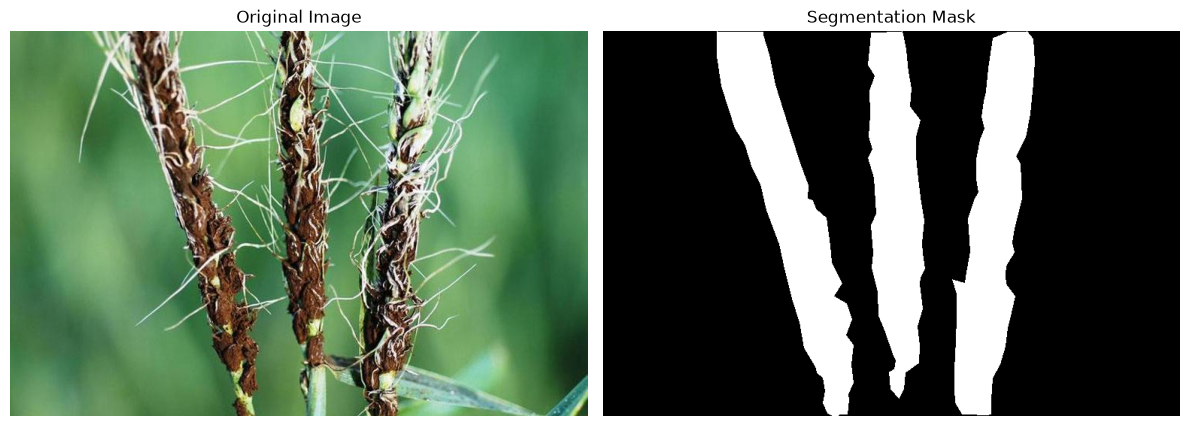

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Mask
axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [34]:
#inspecting a few more examples of images and their corresponding masks

sample_df = df_clean.sample(6 , random_state=42)

for _,row in sample_df.iterrows():
    print(
        row["Plant"]," | ",row["Disease"]," | Mask ratio : ",round(row["Mask ratio"],4)
    )

Grape  |  grape downy mildew  | Mask ratio :  0.2116
Tomato  |  tomato early blight  | Mask ratio :  0.2076
Bean  |  bean rust  | Mask ratio :  0.3154
Soybean  |  soybean frog eye leaf spot  | Mask ratio :  0.2169
Squash  |  squash powdery mildew  | Mask ratio :  0.3357
Apple  |  apple scab  | Mask ratio :  0.0086


In [35]:
# Inspect the 6 images with the smallest mask ratios

lowest_mask_samples = (
    df_clean
    .sort_values("Mask ratio")
    [["Name", "Plant", "Disease", "Mask ratio", "Label file"]]
    .head(6)
)

display(lowest_mask_samples)

,Name,Plant,Disease,Mask ratio,Label file
6220,apple_black_rot_google_0001.jpg,Apple,apple black rot,0.000042,apple_black_rot_google_0001.png
1420,cherry_leaf_spot_google_0148.jpg,Cherry,cherry leaf spot,0.000203,cherry_leaf_spot_google_0148.png
2791,ginger_leaf_spot_6.jpg,Ginger,ginger leaf spot,0.000440,ginger_leaf_spot_6.png
2819,ginger_sheath_blight_42.jpg,Ginger,ginger sheath blight,0.000575,ginger_sheath_blight_42.png
1397,cherry_leaf_spot_61.jpg,Cherry,cherry leaf spot,0.000932,cherry_leaf_spot_61.png
6291,apple_scab_google_0284.jpg,Apple,apple scab,0.001059,apple_scab_google_0284.png


In [36]:
# Examine the distribution of mask ratios

print("Minimum mask ratio:",
      df_clean["Mask ratio"].min())

print("Maximum mask ratio:",
      df_clean["Mask ratio"].max())

print("\nMask ratio percentiles:")
print(
    df_clean["Mask ratio"].quantile(
        [0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Minimum mask ratio: 4.2253181060917016e-05
Maximum mask ratio: 1.0

Mask ratio percentiles:
0.001    0.001552
0.010    0.004660
0.050    0.015010
0.100    0.026538
0.250    0.059539
0.500    0.138957
0.750    0.300471
0.900    0.526828
0.950    0.677887
0.990    0.916903
Name: Mask ratio, dtype: float64
